# Predicting short term BTC returns from order book flow 

This notebook explores methods for utilising LOB data (up to 20 levels) and various ML/deep learning models to predict short term price movements in BTC as part of an order flow/momentum trading strategy. 

In [131]:
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm

%load_ext autoreload
%autoreload 2
%matplotlib inline 

import lakeapi
import datetime as dt
from datetime import timedelta, datetime, date, time
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import time
import plotly.graph_objects as go 
import mplfinance as mpf
from scipy.stats import pearsonr
from itertools import product

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_rows', 100)

from xgboost import plot_importance
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm
import seaborn as sns

#my functions 
from helpers import make_features
from train import walk_forward_validate
from eda import qq_plot, plot_kde

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The data comprises of 10 second snapshots in BTC order book (top 20 levels) from Binance exchange from around October 2025 - December 2025. I have created ~ 50 features related to order book flow such as bid ask spread, price momentum, etc. 

In [77]:
#global variables 

PARAMS = {
    #General params 
    'device': 'cpu', 
    'enable_categorical': True,
    #Tree params
    'booster': 'gbtree',
    #Learning Task Params 
    'objective': 'reg:absoluteerror', 
}

TRAIN_TEST_SPLIT_PARAMS = {
    'num_splits': 10, 
    'split_ratio': 0.8, 
}

TARGET = 'fwd_ret_3_bp'

QR_PARAMS = {
    'alpha': 0.0,
}
BASIS_POINTS_CONVERSION = 10_000
HOLDING_PERIODS =  [3, 6, 18, 30, 60, 120, 300]

In [ ]:
#import/load raw data 
raw_df = pd.read_parquet("data/crypto_book_10s_data.parquet")
df, FEAS_LIST = make_features(raw_df)
train_df = df.loc[:'2025-12-19'].dropna()

In [64]:
len(train_df)

690900

To reserve data for testing we limit training_df to approximately the first month of data.

# Initial Diagnostics/EDA 

## Target Variable(s)

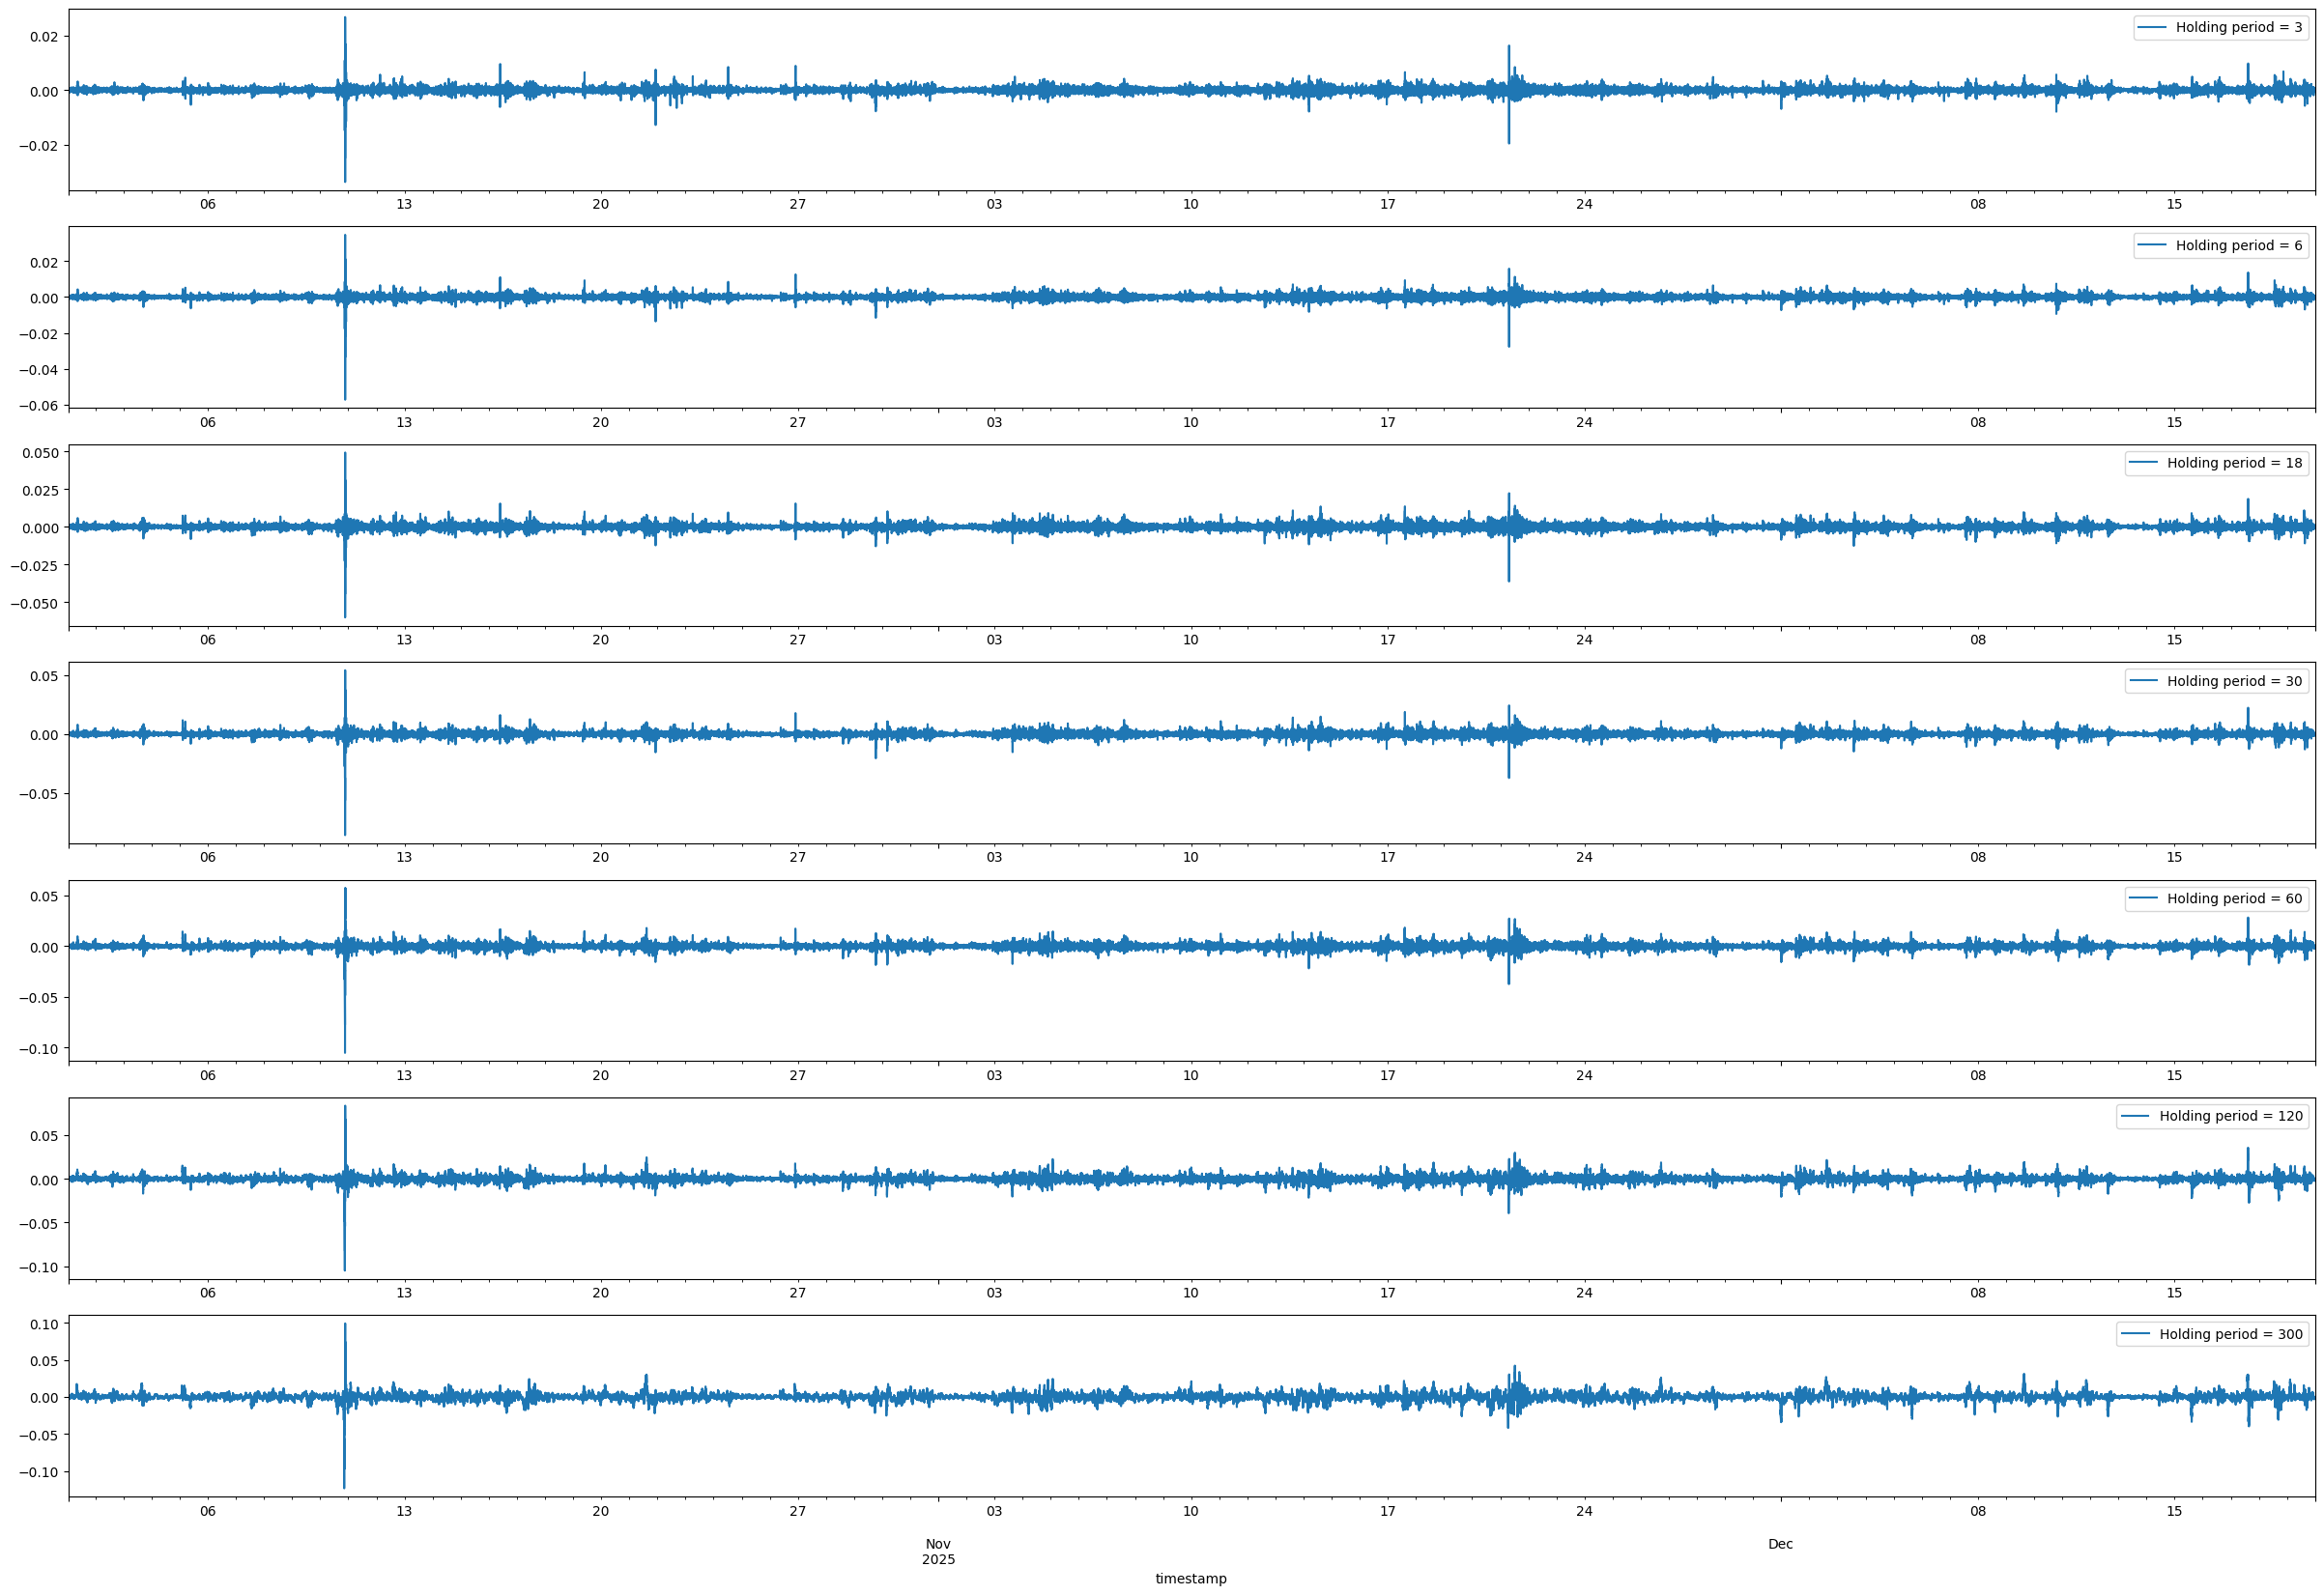

In [62]:
#Plot target variable 
InteractiveShell.ast_node_interactivity = "last_expr"
fig, ax = plt.subplots(nrows = len(HOLDING_PERIODS), figsize = (30, 20))
for h, a in zip(HOLDING_PERIODS, ax): 
    train_df[f'fwd_ret_{h}'].plot(ax = a, label = f'Holding period = {h}')
    a.legend()

In [46]:
train_df[[f'fwd_ret_{h}' for h in HOLDING_PERIODS]].describe()

,fwd_ret_3,fwd_ret_6,fwd_ret_18,fwd_ret_30,fwd_ret_60,fwd_ret_120,fwd_ret_300
count,6.909000e+05,690900.000000,6.909000e+05,690900.000000,690900.000000,690900.000000,690900.000000
mean,-9.963110e-07,-0.000002,-6.007584e-06,-0.000010,-0.000020,-0.000040,-0.000101
std,4.942494e-04,0.000699,1.197131e-03,0.001551,0.002199,0.003084,0.004826
min,-3.366100e-02,-0.057293,-6.010238e-02,-0.085475,-0.105378,-0.105026,-0.123602
25%,-1.994594e-04,-0.000296,-5.299379e-04,-0.000692,-0.000982,-0.001382,-0.002152
50%,0.000000e+00,0.000000,-8.192209e-08,-0.000009,-0.000016,-0.000011,-0.000013
75%,1.984052e-04,0.000294,5.139848e-04,0.000666,0.000952,0.001332,0.002116
max,2.676703e-02,0.034734,4.925698e-02,0.053936,0.057609,0.083828,0.099354


Note that percentage returns are very small - we follow conventions that standardise returns in terms of basis points (1 basis point = 0.01%). Also note the fact there are some HUGE outliers. 

In [65]:
train_df[[f'fwd_ret_{h}_bp' for h in HOLDING_PERIODS]].describe()

,fwd_ret_3_bp,fwd_ret_6_bp,fwd_ret_18_bp,fwd_ret_30_bp,fwd_ret_60_bp,fwd_ret_120_bp,fwd_ret_300_bp
count,690900.000000,690900.000000,690900.000000,690900.000000,690900.000000,690900.000000,690900.000000
mean,-0.009963,-0.019938,-0.060076,-0.100197,-0.200937,-0.402948,-1.011883
std,4.942494,6.987235,11.971309,15.507527,21.985044,30.844710,48.258267
min,-336.609966,-572.933268,-601.023786,-854.751536,-1053.778620,-1050.258046,-1236.019812
25%,-1.994594,-2.956843,-5.299379,-6.915953,-9.816336,-13.819362,-21.524704
50%,0.000000,0.000000,-0.000819,-0.094306,-0.158115,-0.113337,-0.134421
75%,1.984052,2.935940,5.139848,6.664601,9.519345,13.316795,21.164221
max,267.670313,347.342778,492.569767,539.358719,576.093917,838.284831,993.536776


From KDE/rug plot below, notice that fwd return values are appproximately symmetic but very fat tailed. 

Also note that median return is approximately zero for shorter frequencies, but this picture changes as we go increase frequency. 

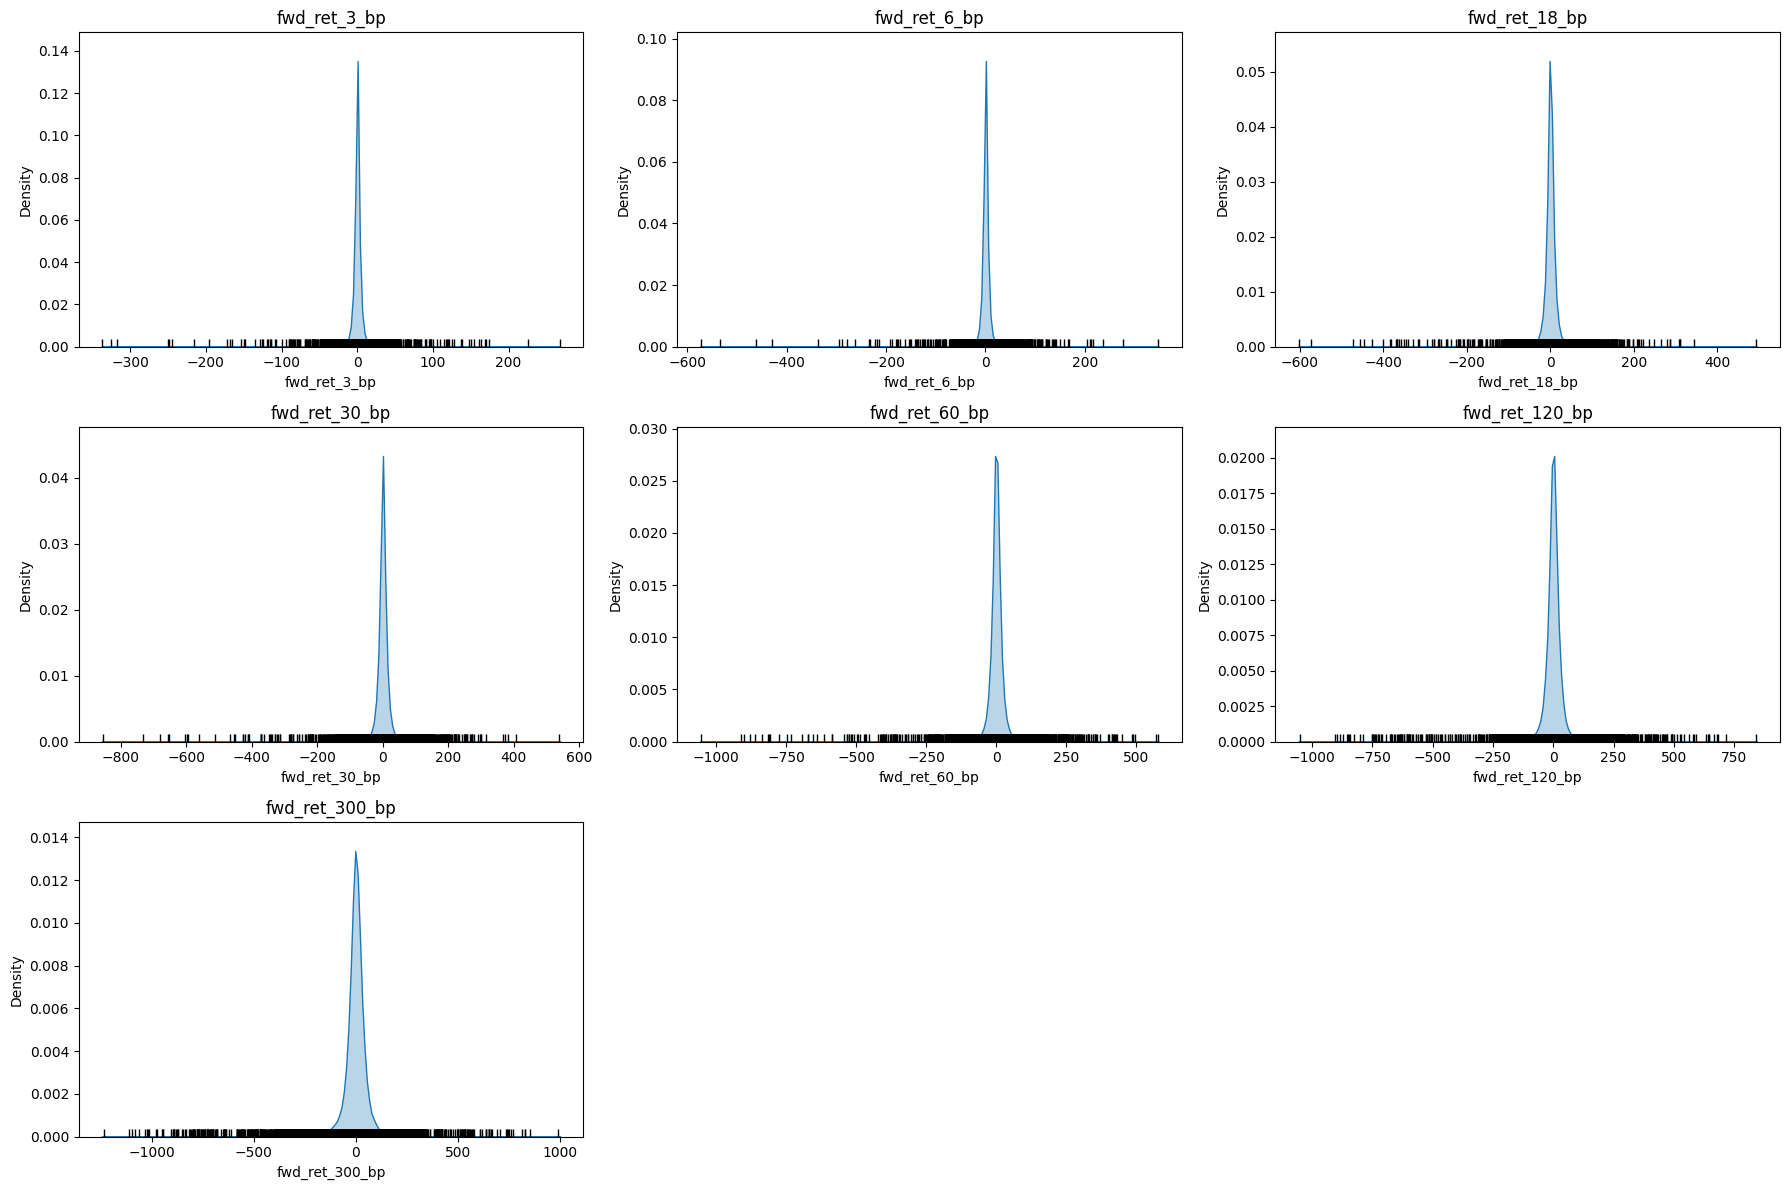

In [66]:
ncols = 3
nrows = int(np.ceil(len(HOLDING_PERIODS) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4*nrows))
axes = axes.flatten()

for ax, h in zip(axes, HOLDING_PERIODS):
    col = f'fwd_ret_{h}_bp'
    sns.kdeplot(data=train_df, x=col, fill=True, alpha=0.3, ax=ax)
    sns.rugplot(data=train_df, x=col, color='black', ax=ax)
    ax.set_title(col)

# hide any empty axes
for ax in axes[len(HOLDING_PERIODS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
### Outlier Analysis - Forward Returns - What happened on this day?

<Axes: >

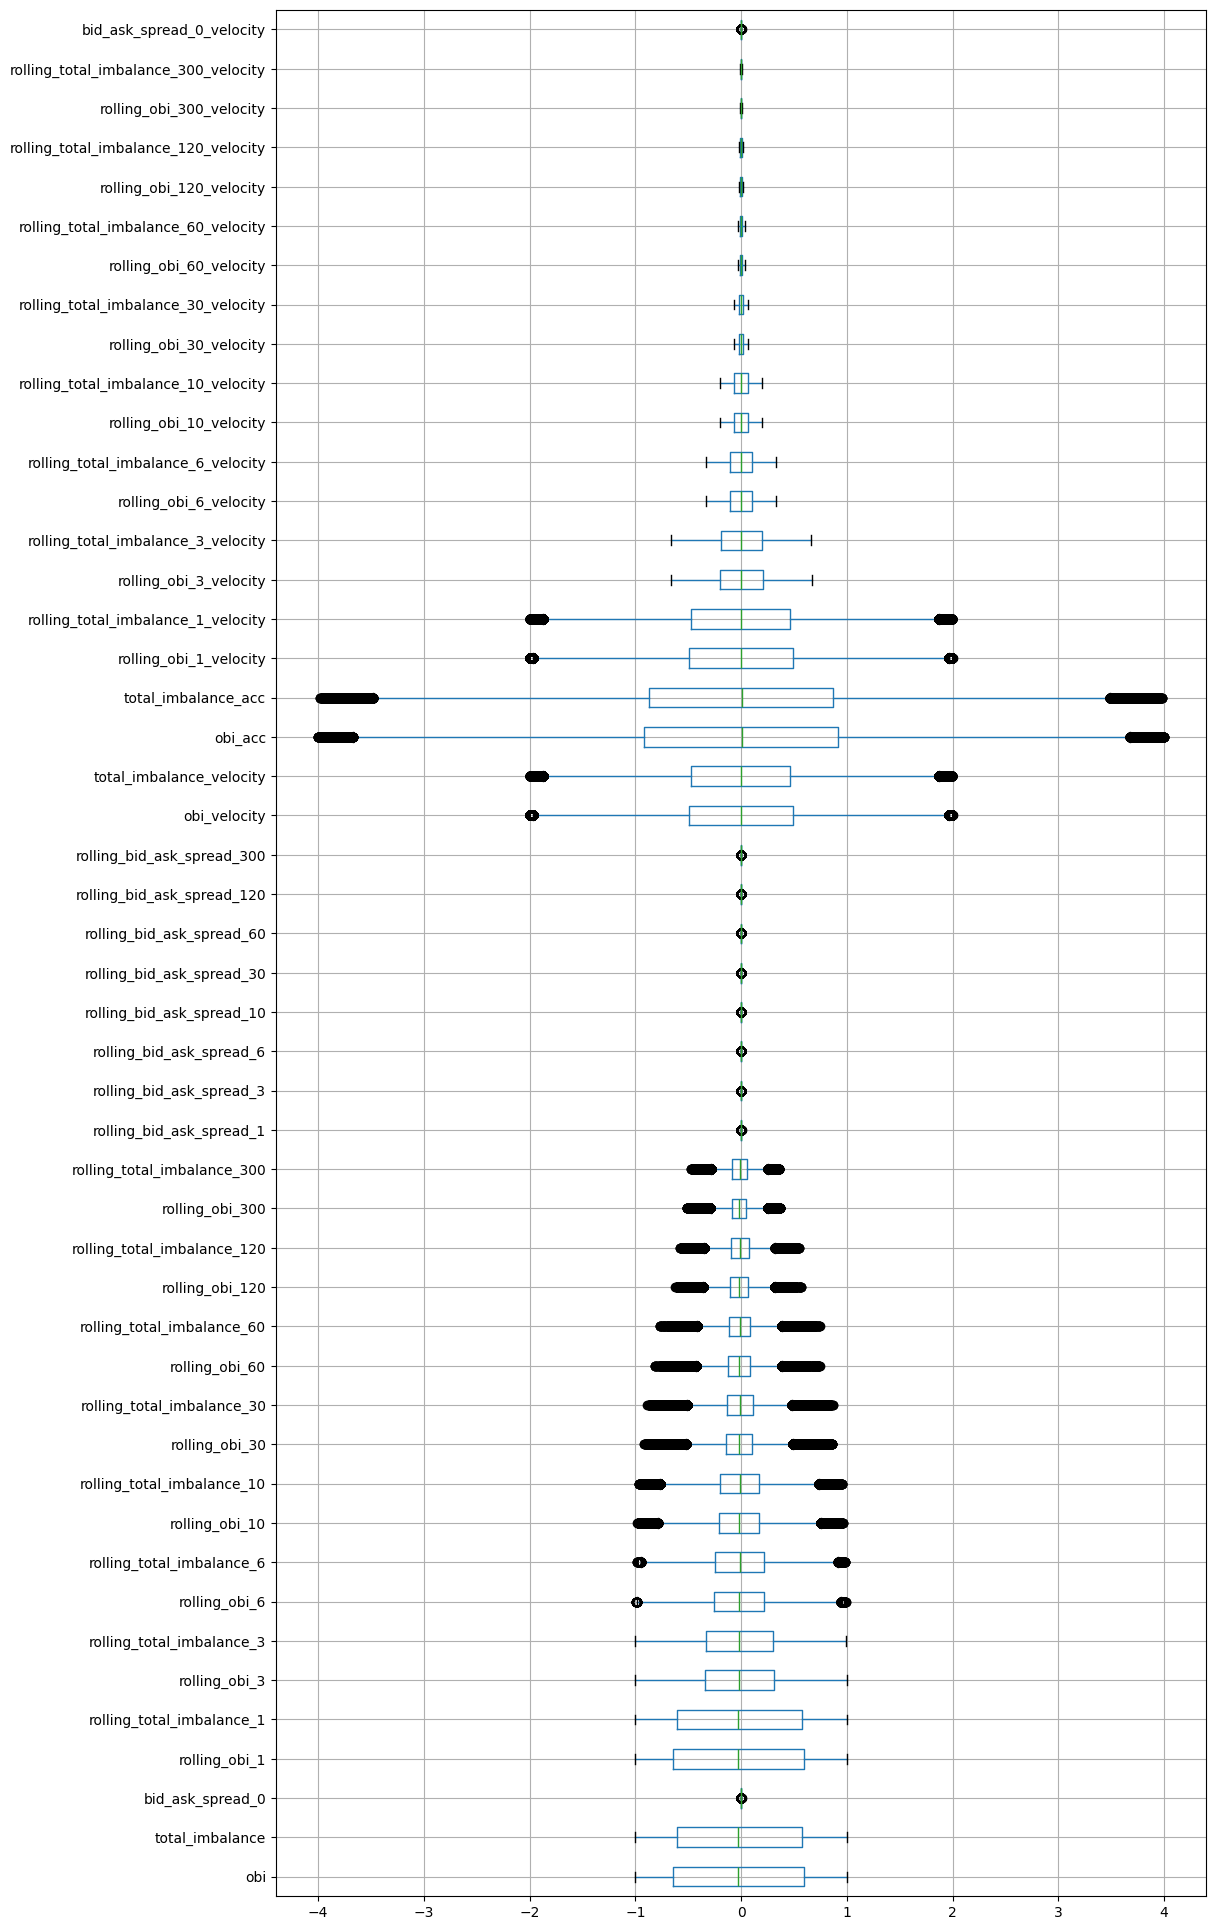

In [ ]:
#Plot summary distributions of other features 
#First - get a sense of approximate unit/scale of each of them/helps gauge whether or not we need to make any relevant TRANSFORMATIONS 
train_df[FEAS_LIST].boxplot(vert=False, figsize=(12, len(FEAS_LIST) * 0.5))

OBI related metrics are standardised to between (-1,1). From the picture below, note that bid/ask spreads are extremely right skewed/fat tailed. It is an open question whether or not we should actually standardise to basis points. 

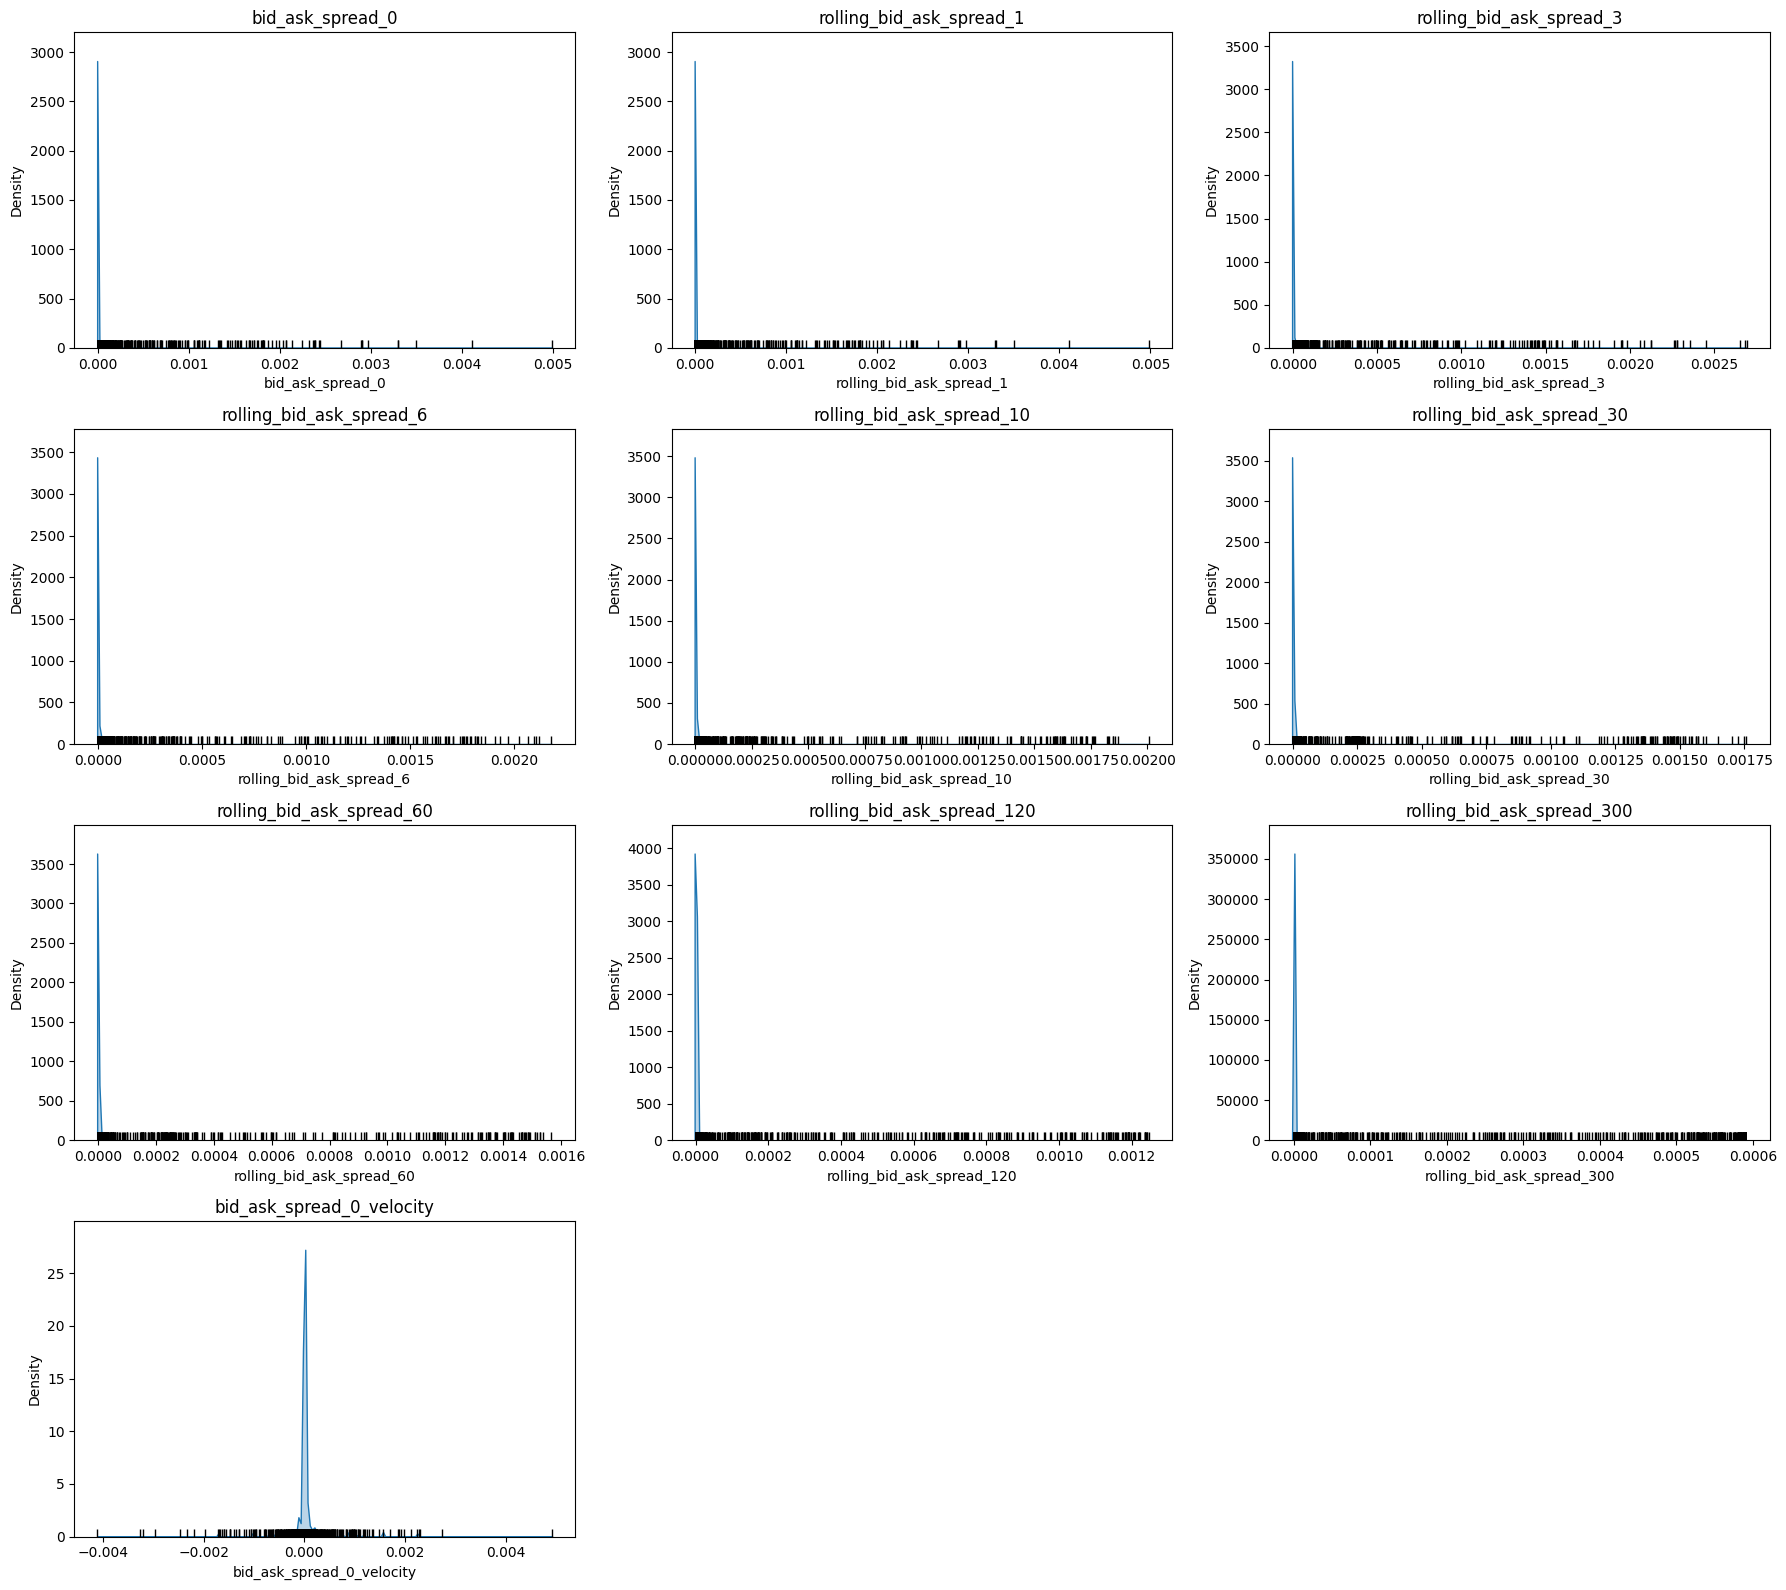

In [82]:
InteractiveShell.ast_node_interactivity = "last_expr"
bid_ask_spread_cols = [col for col in train_df.columns if 'bid_ask_spread' in col]
ncols = 3
nrows = int(np.ceil(len(bid_ask_spread_cols) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, bid_ask_spread_cols):
    sns.kdeplot(data=train_df, x=col, fill=True, alpha=0.3, ax=ax)
    sns.rugplot(data=train_df, x=col, color='black', ax=ax)
    ax.set_title(col)

# hide any empty axes
for ax in axes[len(bid_ask_spread_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Relationships between target/features 

Time consuming, but helps to just do a couple of blocks to get a sense of what the data/relationships look like. 

In [125]:
### Mass correlation (naive measure) - of monotonic relationships 
train_df[['fwd_ret_3_bp']+ FEAS_LIST].corr()['fwd_ret_3_bp'].sort_values(ascending=False)

fwd_ret_3_bp                            1.000000
obi                                     0.115246
rolling_obi_1                           0.115246
rolling_total_imbalance_1               0.115146
total_imbalance                         0.115146
imbalance_flag                          0.096789
rolling_obi_3_velocity                  0.084961
rolling_total_imbalance_3_velocity      0.084690
rolling_obi_10_velocity                 0.084435
rolling_total_imbalance_10_velocity     0.084158
rolling_obi_300_velocity                0.083610
rolling_total_imbalance_300_velocity    0.083529
rolling_obi_6_velocity                  0.083137
rolling_total_imbalance_6_velocity      0.083093
rolling_total_imbalance_30_velocity     0.082898
rolling_obi_30_velocity                 0.082857
rolling_total_imbalance_60_velocity     0.082110
rolling_obi_60_velocity                 0.082058
rolling_obi_120_velocity                0.082044
rolling_total_imbalance_120_velocity    0.081665
rolling_total_imbala

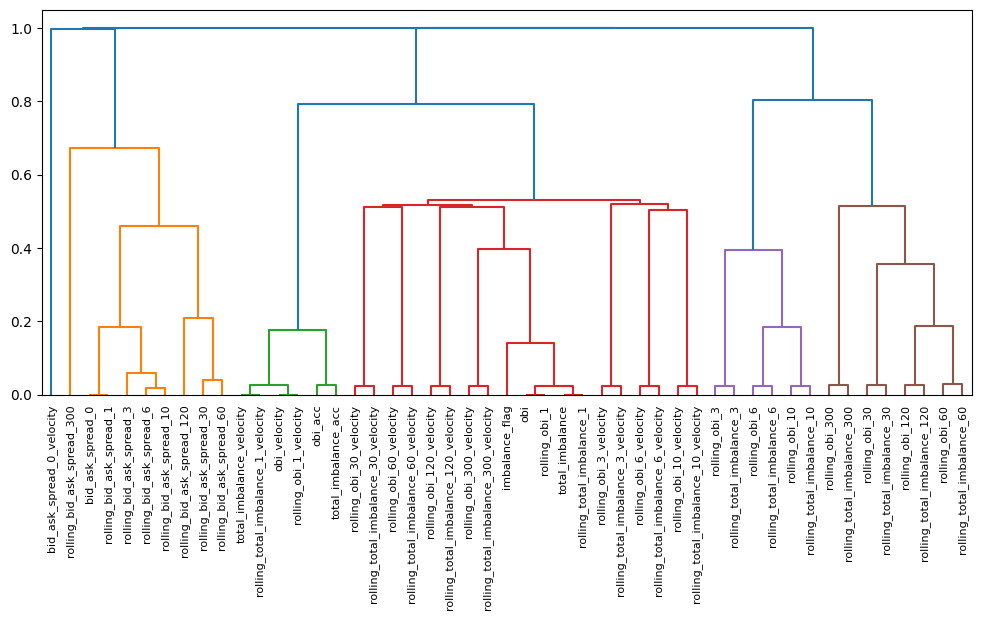

In [143]:
## Interfeature correlation - how to visualise? This is how we can prioritise what features to drill down on/analysefrom scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

plt.figure(figsize = (12,5))
dissimilarity = 1 - abs(train_df[FEAS_LIST].corr())
Z = linkage(squareform(dissimilarity), 'complete')

dendrogram(Z, labels=train_df[FEAS_LIST].columns, orientation='top', leaf_rotation=90);

We have visualised the correlation clustered as a dendrogram. The main takeaway is that there is very quite a strong correlation between total (instantantaneous) order book imbalance and top level order book imbalance. The representative features we can do EDA are: 
1. bid/ask spread velocity 
2. Rolling bid ask spread measures - just choose maybe 3 (short, medium, long)
3. order book imbalance - velocity/acceleration 
4. rolling imbalance - velocity/acceleration (short, medium long)

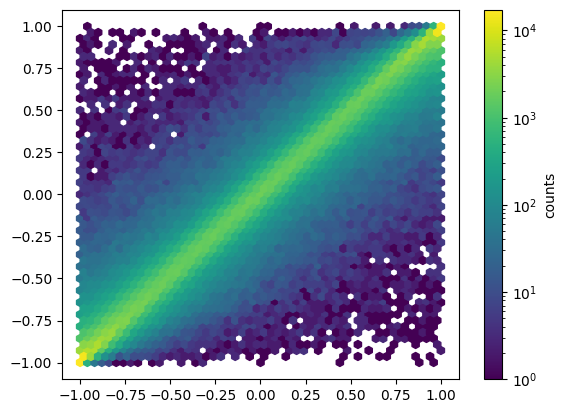

In [144]:
fig, ax = plt.subplots()
hb = ax.hexbin(train_df['obi'], train_df['total_imbalance'], gridsize=50, bins = 'log')
cb = fig.colorbar(hb, ax=ax, label='counts')

### Representative Feature 1 - Order Book Imbalance 

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /eda.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  


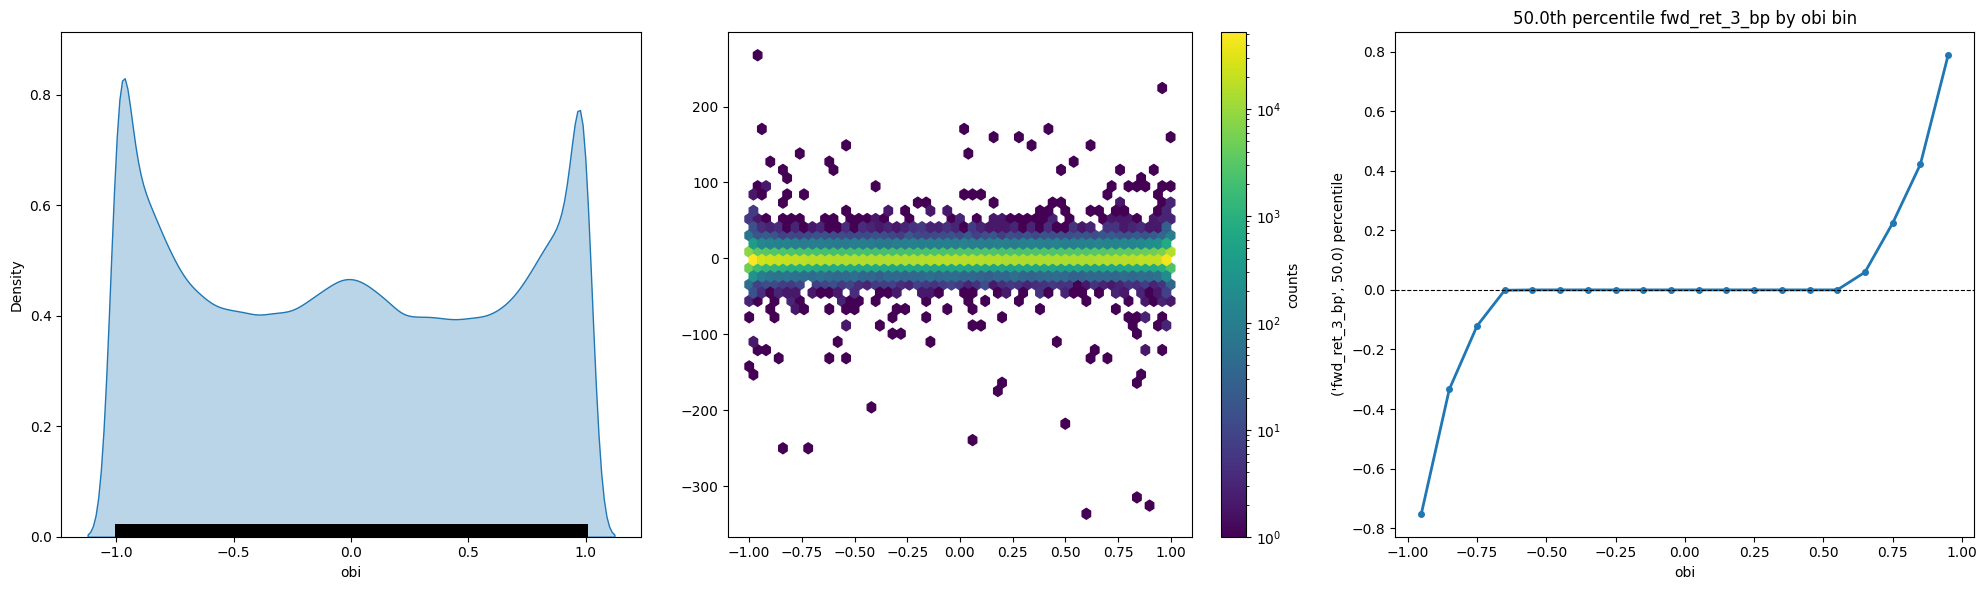

In [ ]:
from eda import plot_feature 
plot_feature(df, 'obi', 'fwd_ret_3_bp')

<Axes: >

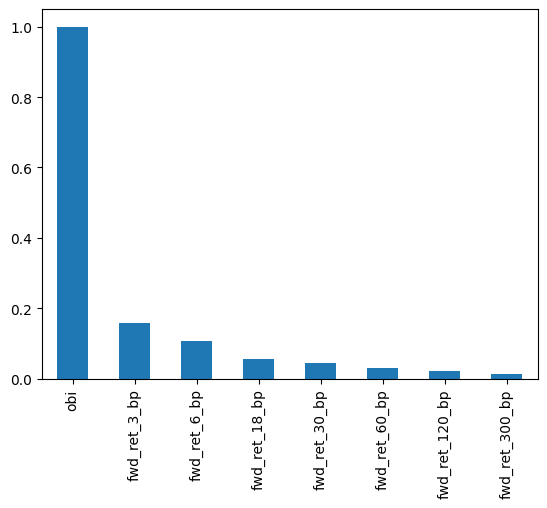

In [165]:
#Future price movements/OBI 
train_df[['obi']+ [f'fwd_ret_{h}_bp' for h in HOLDING_PERIODS]].corr('spearman')['obi'].plot.bar()

Correlation between obi and fwd returns is strongest for shortest term horizons. 

In [ ]:
### Velocity 
plot_feature(df, 'obi_velocity', 'fwd_ret_3_bp', figsize = (20, 5))

In [ ]:
# Model Comparisons:a Baseline Model, Decision Tree, Linear Quantile Regression 

In [ ]:
# Iteration 2 - How many models do we need? 